# <center>[MAIN QUEST 01] Space Titanic </center>

[프로젝트 기간] 2026-06-09

이 퀘스트는 `Kaggle`의 `GettingStarted Prediction Competition`시리즈 중 하나이다.

[목표]
- 성간 여객선인 타이타닉호가 시공간 이상 현상과 충돌했을 때 `어떤 승객`이 다른 차원으로 `이동`했는지 여부를 예측
- Submission 기준 : `Classification Accuracy`

---

# [목차]

- 1. IMPORTS
- 2. 탐색적 데이터 분석 (EDA)
    - 2.1 타겟 분포 분석
    - 2.2 개별 변수 탐색
        - 2.2.1 수치형 변수 분포
        - 2.2.2 범주형 변수 분포
- 3. 데이터 전처리(Data Cleaning & Preprocessing)
    - 3.1 결측치 처리
    - 3.2 텍스트 및 범주형 변수 변환
- 4. 상관관계 및 피처 엔지니어링
    - 4.1 전체 변수 상관관계 분석
    - 4.2 다중공선성 제거 및 피처 선택
- 5. 모델링
    - 5.1 데이터 분리 (Train/Validation Split)
    - 5.2 기본 모델 선정 및 학습 (Baseline Models)
    - 5.3 모델 평가
    - 5.4 피처 엔지니어링 (파생변수 추가)
    - 5.5 교차 검증 (K-Fold Cross Validation)
    - 5.6 하이퍼파라미터 튜닝 (Bayesian)
    - 5.7 모델 블렌딩 (Blending)
- 6. 서브미션 파일 내보내기
- 7. NOTE
- 8. Reference

# <center>1. IMPORTS</center>


## 라이브러리 불러오기

In [3]:
from IPython.display import clear_output
!pip3 install -U lazypredict
!pip3 install -U pandas #Upgrading pandas
!pip3 install -U xgboost==3.0.2 lightgbm==4.6.0 missingno==0.5.2 catboost hyperopt

clear_output()

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid', font_scale=1.4)
import os
from os.path import join
import datetime
import missingno as msno

# Sklearn
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import StratifiedKFold

# Model
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# HyperParameters
from hyperopt import hp
from hyperopt import fmin, tpe, Trials

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 데이터 로딩

In [5]:
data_path = "./data"

train_data_path = join(data_path, 'train.csv')
test_data_path = join(data_path, 'test.csv')

df_train = pd.read_csv(train_data_path)
df_test = pd.read_csv(test_data_path)

print("데이터 로딩 완료")

데이터 로딩 완료


## Data Description
1. **PassengerId** - <font size="3">승객 고유의 ID. gggg_pp 형태로 구성되어 있으며, 여기서 gggg는 승객이 함께 여행하는 그룹을 나타내고 pp는 그룹 내에서의 번호를 의미한다. 그룹으로 묶인 사람들은 대개 가족인 경우가 많지만, 항상 그렇지는 않다.</font>
2. **HomePlanet** - <font size="3">승객이 출발한 행성으로, 주로 승객이 영구 거주하던 행성을 의미한다.</font>
3. **CryoSleep** - <font size="3">승객이 항해 기간 동안 저체온 가사(동면) 상태를 선택했는지 여부. 동면 상태인 승객은 자신의 객실(Cabin) 안에만 갇혀 있게 된다.</font>
4. **Cabin** - <font size="3">승객이 머무는 객실 번호. deck/num/side 형태로 구성되며, 여기서 side는 P(Port, 좌현) 또는 S(Starboard, 우현) 중 하나가 된다.</font>
5. **Destination** - <font size="3">승객이 하선할 목적지 행성</font>
6. **Age** - <font size="3">승객의 나이</font>
7. **VIP** - 승객이 항해 중 특별 VIP 서비스를 이용하기 위해 추가 비용을 지불했는지 여부</font>
8. **RoomService, FoodCourt, ShoppingMall, Spa, VRDeck** - <font size="3">우주선 타이타닉호에 있는 다양한 호화 편의시설(룸서비스, 푸드코트, 쇼핑몰, 스파, VR룸)에서 승객이 각각 청구받은 금액</font>
9. **Name** - <font size="3">승객의 이름과 성(First and Last names)</font>
10. <span style="color:blue">**Transported** - <font size="3">승객이 다른 차원으로 이동(실종)되었는지 여부. 우리가 예측해야 하는 타겟(정답) 컬럼.</font></span>

<a id="3.1"></a>
## <span style="color:#e76f51;"> Exploring Train Data : </span>

<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana; line-height: 1.7em;">
    📌 &nbsp;<b><u>학습 데이터 정보:</u></b><br>

* <i> 총 <b><u>14</u></b> 컬럼과 <b><u>8693</u></b> 행으로 이루어짐.</i><br>
* <i> <b><u>119378</u></b> 개의 값을 포함하며, <b><u>2324</u></b>개 결측치가 존재.</i><br>
* <i> 12개의 컬럼에서 결측치가 확인되며, 그 중 <b><u>CryoSleep</u></b>가 가장 많은 결측치를 가지고 있음 <u>(217)</u>  </i><br>
* <i> 타겟인 <b><u>Transported</u></b>은 <b><u>train</u></b> 데이터셋에만 존재.</i><br>
</div>


In [6]:
df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [7]:
print(f'\033[94mNumber of rows in train data: {df_train.shape[0]}')
print(f'\033[94mNumber of columns in train data: {df_train.shape[1]}')
print(f'\033[94mNumber of values in train data: {df_train.count().sum()}')
print(f'\033[94mNumber missing values in train data: {sum(df_train.isna().sum())}')

# 14개의 컬럼으로 구성된 8693행으로 구성된 데이터 119378개 중, 결측치는 2324개임을 확인.

Number of rows in train data: 8693
Number of columns in train data: 14
Number of values in train data: 119378
Number missing values in train data: 2324


CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
Spa             183
FoodCourt       183
Destination     182
RoomService     181
Age             179
PassengerId       0
Transported       0
dtype: int64


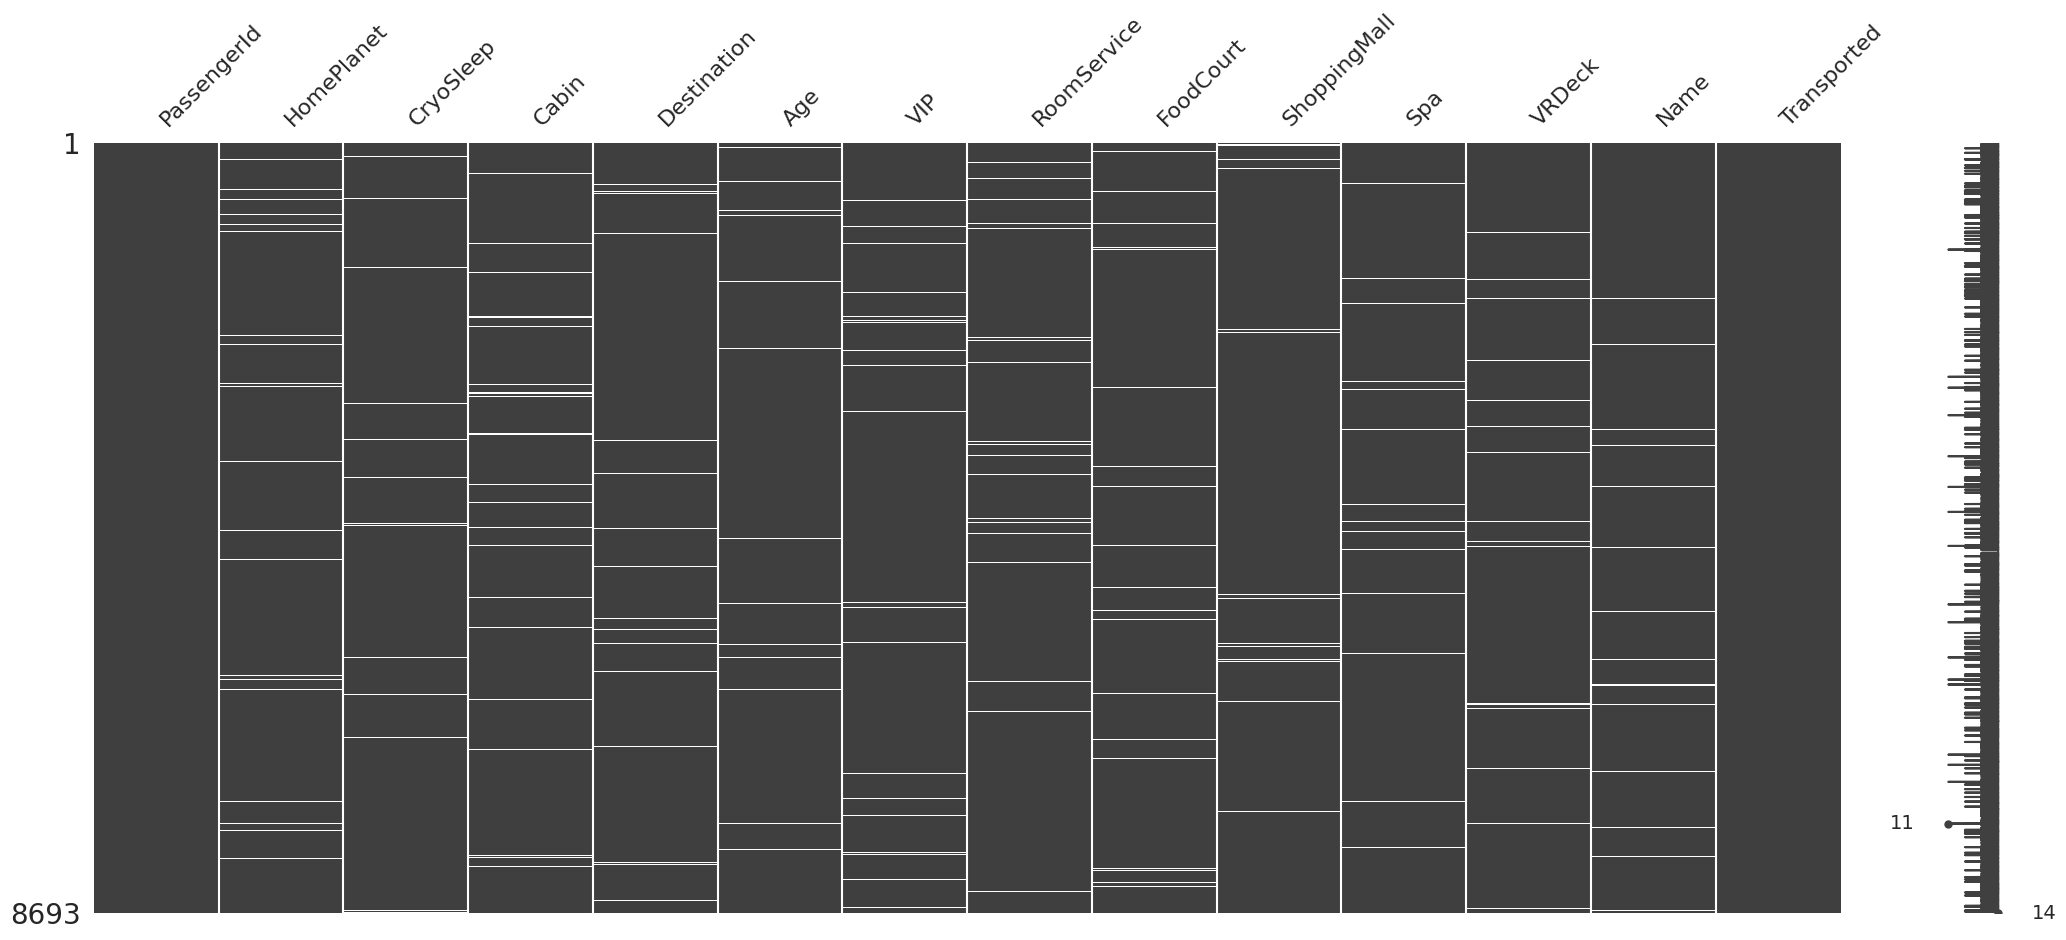

In [8]:
# Chek Missing Data
print((df_train.isna().sum().sort_values(ascending = False)))

msno.matrix(df_train)
plt.show()

In [9]:
df_train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


- RoomService, FoodCourt, ShoppingMall, Spa, VRDeck 변수:   
    최소값과 최대값의 차이가 크고, 중앙값과 평균값의 차이가 명확함으로 해당 변수들의 분포는 오른쪽 꼬리가 긴 그래프를 형성할 것으로 보인다.

<a id="3.1"></a>
## <span style="color:#e76f51;"> Exploring Test Data : </span>

<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana; line-height: 1.7em;">
    📌 &nbsp;<b><u>테스트 데이터 정보:</u></b><br>

* <i> 총 <b><u>13</u></b> 컬럼과 <b><u>4277</u></b> 행으로 이루어짐.</i><br>
* <i> <b><u>54484</u></b> 개의 값을 포함하며, <b><u>1117</u></b>개 결측치가 존재.</i><br>
* <i> 12개의 컬럼에서 결측치가 확인되며, 그 중 <b><u>FooCourt</u></b>가 가장 많은 결측치를 가지고 있음 <u>(106)</u>  </i><br>
</div>


In [10]:
print(f'\033[94mNumber of rows in test data: {df_test.shape[0]}')
print(f'\033[94mNumber of columns in test data: {df_test.shape[1]}')
print(f'\033[94mNumber of values in test data: {df_test.count().sum()}')
print(f'\033[94mNumber missing values in test data: {sum(df_test.isna().sum())}')

# 13개의 컬럼으로 구성된 4277행으로 구성된 데이터 54484개 중, 결측치는 1117개임을 확인.

Number of rows in test data: 4277
Number of columns in test data: 13
Number of values in test data: 54484
Number missing values in test data: 1117


FoodCourt       106
Spa             101
Cabin           100
ShoppingMall     98
Name             94
VIP              93
CryoSleep        93
Destination      92
Age              91
HomePlanet       87
RoomService      82
VRDeck           80
PassengerId       0
dtype: int64


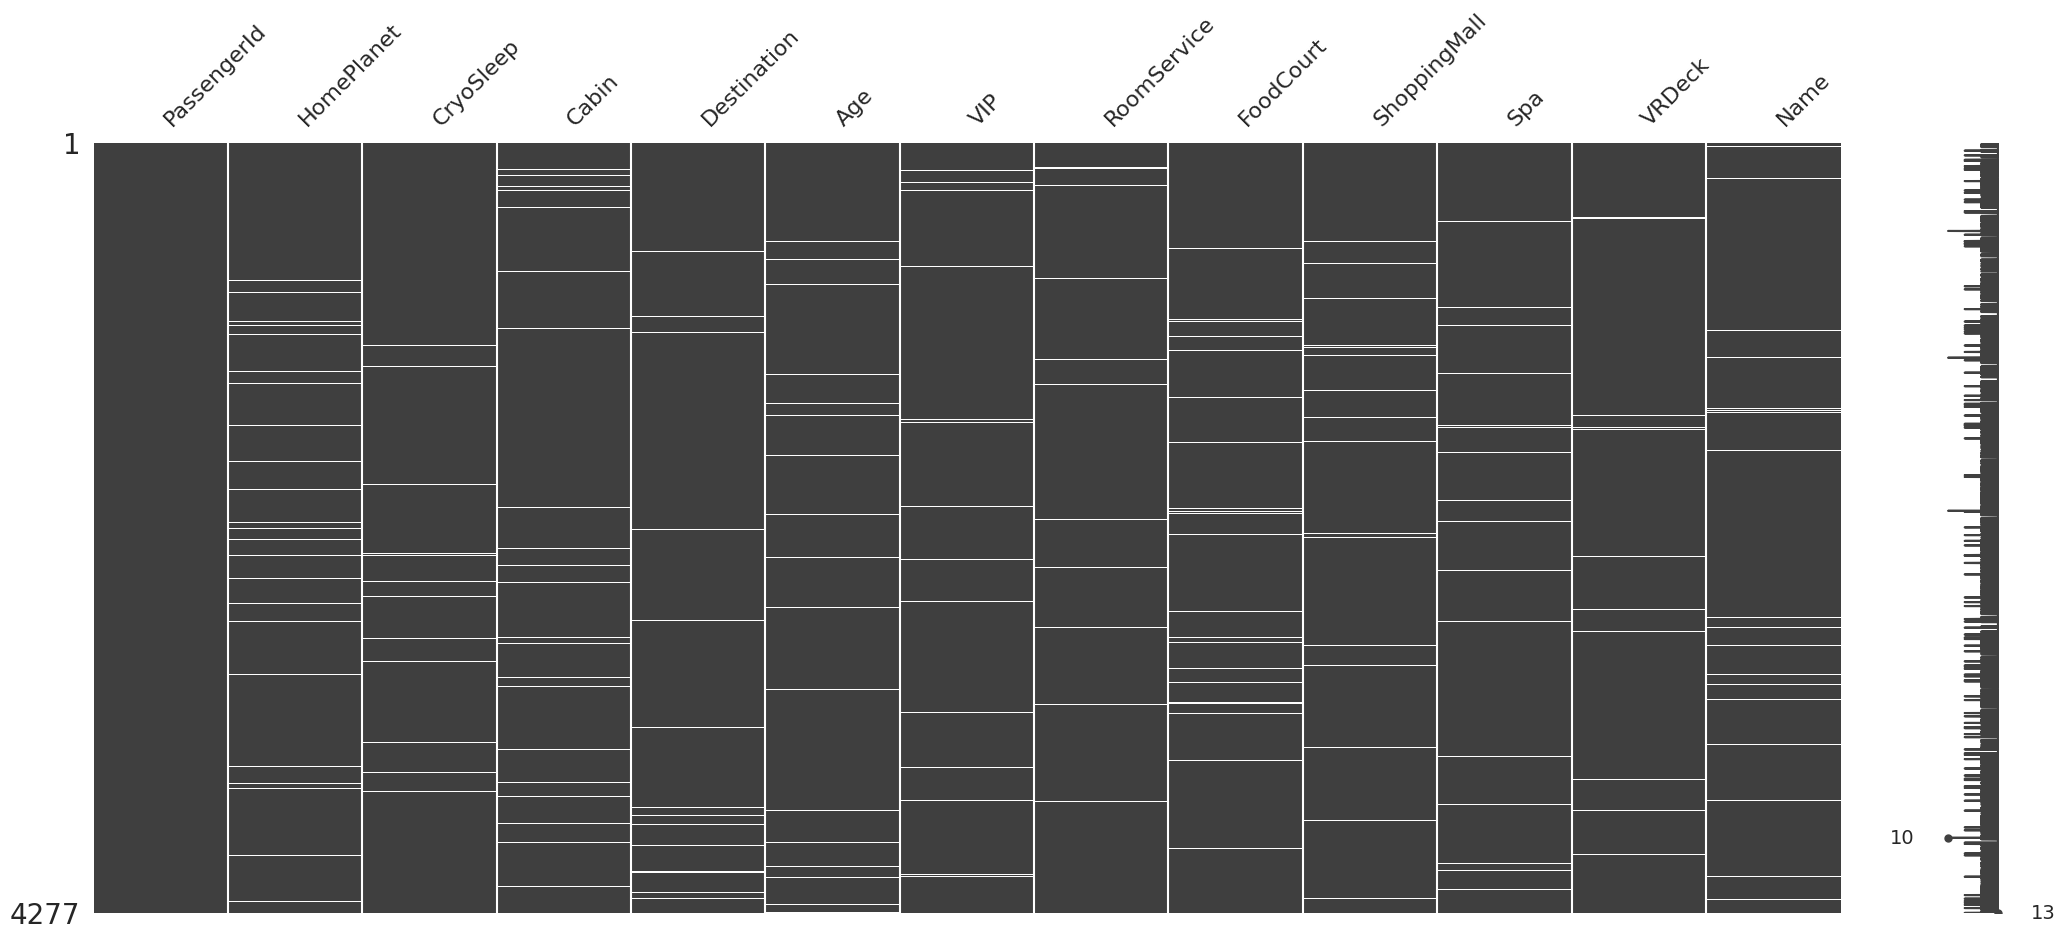

In [11]:
# Chek Missing Data
print((df_test.isna().sum().sort_values(ascending = False)))

msno.matrix(df_test)
plt.show()

In [12]:
df_test.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,4186.000000,4195.000000,4171.000000,4179.000000,4176.000000,4197.000000
mean,28.658146,219.266269,439.484296,177.295525,303.052443,310.710031
std,14.179072,607.011289,1527.663045,560.821123,1117.186015,1246.994742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,53.000000,78.000000,33.000000,50.000000,36.000000
max,79.000000,11567.000000,25273.000000,8292.000000,19844.000000,22272.000000


### [전처리 계획]

1. PasaengerId에서 그룹번호은 일행 또는 가족을 의미하는 정보를 담고 있으므로 슬라이싱을 통한 파생 변수 생성 고려.
2. Cabin은 Deck/Num/Side가 합쳐져 있으므로 통한 파생 변수 생성 고려. 필요에 다라 원핫 인코딩 적용 고려.
3. 비용 변수(RoomService, FoodCourt, ShoppingMall, Spa, VRDeck)는 지출여부(0 또는 1)로 이진화를 통한 파생 변수 생성 고려
4. HomePlanet, Destination, 등 순서가 없는 명목형 변수들은 모델이 인식할 수 있도록 원핫 인코딩 적용을 고려함.
5. Age는 구간나누기 고려.

# <center>2. 탐색적 데이터 분석(EDA)</center>

In [13]:
# 학습 데이터에서 라벨 제거

# 타겟인 Transported 컬럼을 y 변수에 저장
y = df_train['Transported'].reset_index(drop=True)
# Transported 컬럼 삭제
del df_train['Transported']

print(df_train.columns)

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name'],
      dtype='str')


In [14]:
# 컬럼 정리
# ID 컬럼은 개별 승객을 구분하기 위해서 부여된 단순 고유 번호이므로 분석 대상에서 제외한다.
# 단, ID 에 포함된 그룹번호는 해당 승객들이 일행 또는 가족이라는 정보를 가지므로 파생 변수로 추가한다.

df_train['Group'] = df_train['PassengerId'].str[0:4]
df_test['Group'] = df_test['PassengerId'].str[0:4]
train = df_train.drop(columns=['PassengerId'])
test = df_test.drop(columns=['PassengerId'])

print(train.columns)
print(test.columns)

Index(['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP',
       'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name',
       'Group'],
      dtype='str')
Index(['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP',
       'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name',
       'Group'],
      dtype='str')


In [15]:
# 학습 데이터와 테스트 데이터 합치기

# 1. 전체적인 데이터 관리를 위해서 train 데이터와 test 데이터 합치기
train_len = len(train)
data = pd.concat((train, test), axis=0, ignore_index=True)
print(data.shape)

(12970, 13)


In [16]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    12682 non-null  str    
 1   CryoSleep     12660 non-null  object 
 2   Cabin         12671 non-null  str    
 3   Destination   12696 non-null  str    
 4   Age           12700 non-null  float64
 5   VIP           12674 non-null  object 
 6   RoomService   12707 non-null  float64
 7   FoodCourt     12681 non-null  float64
 8   ShoppingMall  12664 non-null  float64
 9   Spa           12686 non-null  float64
 10  VRDeck        12702 non-null  float64
 11  Name          12676 non-null  str    
 12  Group         12970 non-null  str    
dtypes: float64(6), object(2), str(5)
memory usage: 1.8+ MB


## 2.1 타겟 분포 분석

<Axes: >

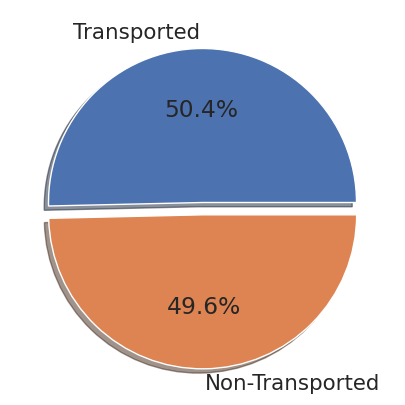

In [17]:
# 차원이동 비율 확인
y.value_counts()  # 차원이동 4378(50.36%), 미이동 4315(49.64%)

plt.figure(figsize=(8, 5))
labels = ['Transported', 'Non-Transported']
y.value_counts().plot.pie(explode=[0, 0.08],
                          shadow=True,
                          autopct='%1.1f%%',
                          labels=labels)

```
차원 이동을 당한 승객(50.4%)와 그렇지 않은 승객(49.6%)의 비율이 거의 동일하다. 따라서 데이터는 균형이 잘 잡혀 있으며, 정확도는 모델 구축에 좋은 기준이 될 것이다.
```

## 2.2 개별 변수 탐색

### 2.2.1 수치형 변수 분포

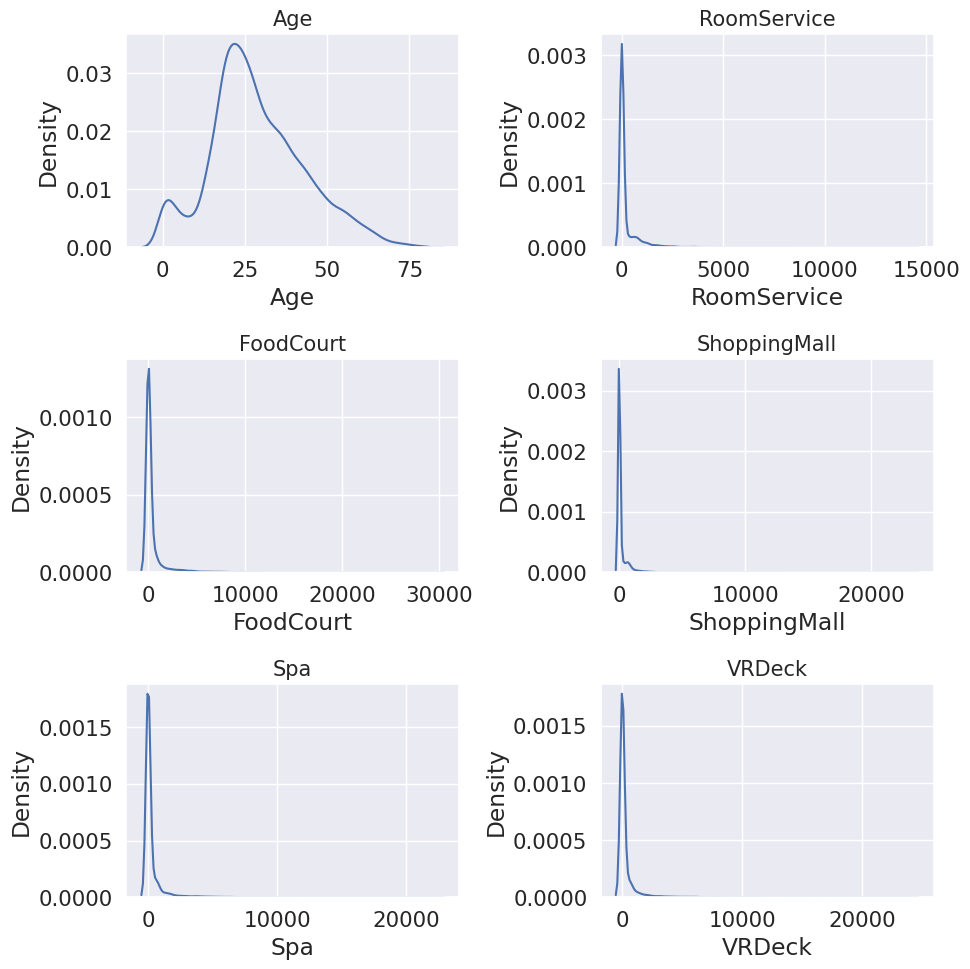

In [18]:
from pandas.api.types import is_numeric_dtype

# 시각화하여 분포 확인

fig, ax = plt.subplots(3, 2, figsize=(10, 10))

# 수치형 특성 컬럼명 리스트로 저장
columns = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
count = 0

for row in range(3):
    for col in range(2):
        # 인덱스 에러 방지 및 안전한 종료 조건
        if count >= len(columns):
            break

        sns.kdeplot(data[columns[count]], ax=ax[row][col])
        ax[row][col].set_title(columns[count], fontsize=15)
        count+=1
    # 안쪽 루프가 break로 끝났거나, count가 다 찼으면 바깥쪽 루프도 종료
    if count >= len(columns):
        break

plt.tight_layout()
plt.show()

```
연속형 변수들의 분포를 살펴보면, 분포가 비대칭적이고 이상치가 존재한다는 것을 알 수 있음.   
따라서 로그 변환과 같은 방법을 고려해 볼 수 있음.

다른 방법으로는 지출이 있는 경우와 없는 경우로 분류하여 범주형으로 변환하는 방법도 고려해 볼 수 있음.
```

### 2.2.2 범주형 변수 분포

In [19]:
# str 또는 object 타입의 컬럼의 데이터 유형 확인
cols_category= ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin']

for col in cols_category:
    print(data[col].value_counts())

HomePlanet
Earth     6865
Europa    3133
Mars      2684
Name: count, dtype: int64
CryoSleep
False    8079
True     4581
Name: count, dtype: int64
Destination
TRAPPIST-1e      8871
55 Cancri e      2641
PSO J318.5-22    1184
Name: count, dtype: int64
VIP
False    12401
True       273
Name: count, dtype: int64
Cabin
G/734/S     8
G/160/P     8
E/13/S      7
B/11/S      7
C/21/P      7
           ..
F/1796/S    1
G/1496/S    1
D/296/P     1
D/297/P     1
G/1498/S    1
Name: count, Length: 9825, dtype: int64


```
5개의 컬럼('HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin') 중 Cabin을 제외한 4개의 컬럼이 순서가 없는 범주형임을 확인.
Cabin은 동일한 객실에 최대 8명, 최소 1명이 배정된다는 사실을 확인할 수 있었지만 더 자세히 분석하기 위해서는 다른 방법이 필요해 보임.
```

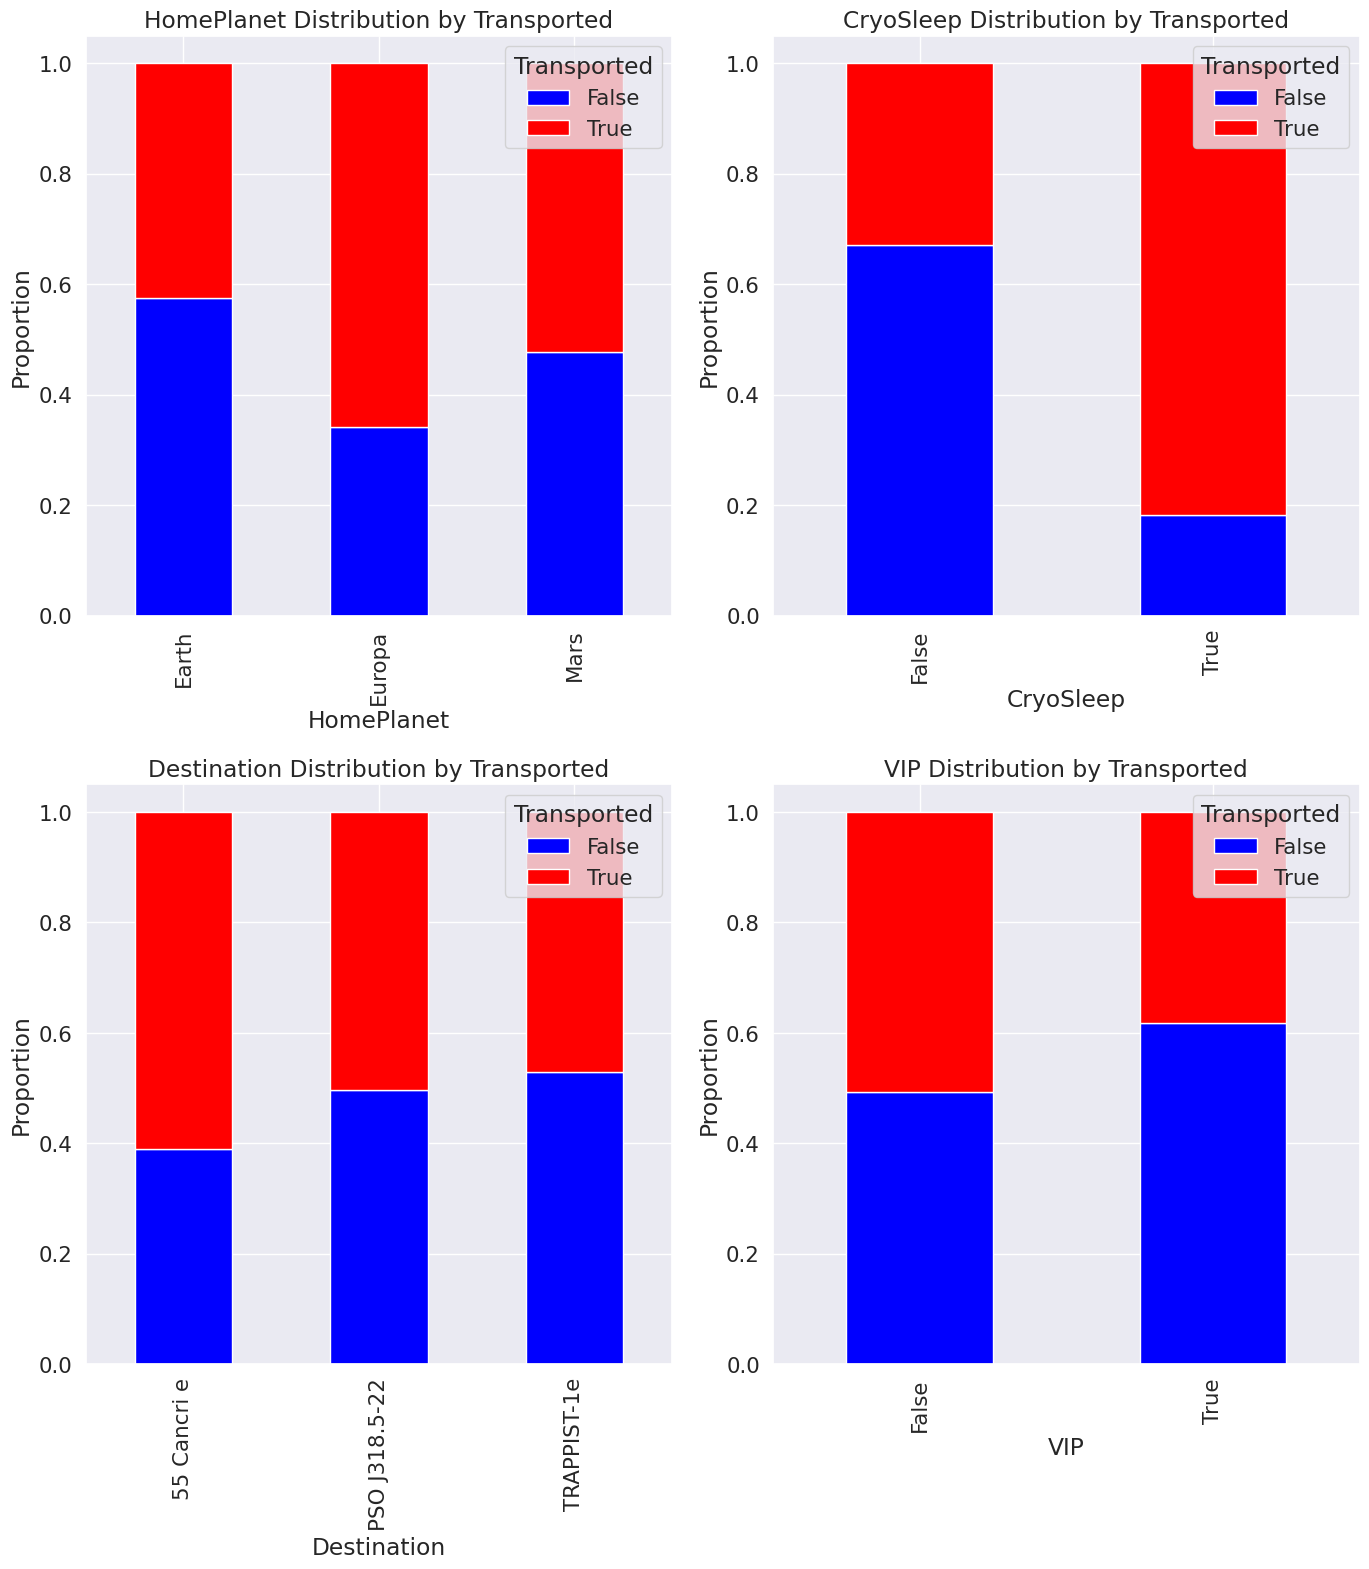

In [20]:
"""
[Error repo]:
            data와 y를 그냥 사용했을 때
            cannot reindex on an axis with duplicate labels 오류 발생
            y 추출, 불필요한 컬럼 drop 한 이후에 ignore_index=True 옵션으로 pd.concat
"""

# 시각화할 범주형 컬럼 리스트 정의
cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

# 그래프 서브플롯 설정 (2x2 배열)
fig, axes = plt.subplots(2, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    if col in data.columns:
        # 교차표 생성 및 비율 정규화
        crosstab = pd.crosstab(data[col], y, normalize='index')

        # 누적 막대그래프 시각화
        crosstab.plot(kind='bar', stacked=True, ax=axes[i], color=['blue', 'red'])

        axes[i].set_title(f'{col} Distribution by Transported')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Proportion')
        axes[i].legend(title='Transported', labels=['False', 'True'])

plt.tight_layout()
plt.show()

```
1. Homeplanet이 Europa인 승객이 가장 많이 실종되었다. 순서는 Europa > Mars > Earth
2. Cryosleep의 경우 동면중이었던 승객의 실종 비율이 약 80%에 달한다
3. 모든 범주들은 계층 내 분포에서 차이를 보인다.
```

In [21]:
# 변수들 간의 상관관계 분석

# 1. 승객 객실 위치와 승객 출발 행성과의 관계
"""
HomePlanet과 Cabin 데이터를 교차해서 보면 deck의 위치와 HomePlanet 간의 상관관계가 존재한 것 처럼 보인다.
이를 확인하기 위해서 교차표를 사용한다. deck 정보는 Cabin에서 슬라이싱 한다.
"""
data['Deck'] = data['Cabin'].str[0]
pd.crosstab(data['HomePlanet'], data['Deck'])


Deck,A,B,C,D,E,F,G,T
HomePlanet,,,,,,,,
Earth,0,0,0,0,583,2426,3700,0
Europa,346,1124,1081,296,197,0,0,10
Mars,0,0,0,406,508,1713,0,0


```
출발 지역에 따라 객실이 위치한 Deck에 차이가 있다는 것을 확인.
Europa는 A~E (주로 B, C), Earth는 E, F, G, Mars는 D, E, F 에 집중되어 있음.
덱의 알파벳 숫자에 어떤 정보가 포함되어 있는 것 처럼 보임.
알파벳 숫자가 높을 수록 최상층 덱이라는 가정 하에 다음 분석을 진행.
```

In [22]:
# 2. 승객 출발 행성과 VIP 서비스 사용 유무 간의 관계

"""
VIP 서비스 사용 유무는 해당 승객의 경제 상태를 나타내는 지표가 될 수 있다.
따라서 출발 행성과 VIP 서비스 사용 유무 사이에 상관관계를 확인할 경우, 앞서 세운 가설에 힘을 실을 수 있다.
"""
pd.crosstab(data['HomePlanet'], data['VIP'])


VIP,False,True
HomePlanet,,
Earth,6706,0
Europa,2883,177
Mars,2533,90


```
VIP 서비스를 이용한 승객은 Europa > Mars > Earth 순으로 많음.
이는 B, C 객실에 몰려있는 Europa 출발 승객들이 상대적으로 부유함을 시사함.
```

In [23]:
# 승객 출발 행성과 냉동 수면의 관계
"""
앞서 출발 행성에 따라 승객 사이의 부유함의 정도가 차이난다는 것을 확인했다.
냉동 수면와 같은 하이 테크놀러지의 경우 일반적으로 많은 비용이 발생하므로, 이 역시 승객 출발 행성과 관계가 있을 것으로 추정된다.
"""
# 행성별 CryoSleep 비율 확인하기 (백분율)
pd.crosstab(data['HomePlanet'], data['CryoSleep'], normalize='index') * 100

CryoSleep,False,True
HomePlanet,,
Earth,69.113697,30.886303
Europa,54.980341,45.019659
Mars,60.579489,39.420511


```
행성별 냉동수면 비율에는 차이가 존재하지만, 가설처럼 특정 출신 행성이 압도적인 수치를 보이진 않음.
따라서 냉동수면과 승객 출발 행성 사이에 강한 상관관계가 있다고는 보기 힘듬.
```

# <center>3. 데이터 전처리 (Data Cleaning & Preprocessing)</center>

## 3.1 결측치 처리

In [24]:
# 학습데이터와 테스트데이터 결측치 비율
train_missing_pct = data.iloc[:train_len,].isnull().mean() * 100
test_missing_pct = data.iloc[train_len:,].isnull().mean() * 100

# 두 데이터셋 결측치 합친 데이터프레임 생성
missing_pct_df = pd.concat([train_missing_pct, test_missing_pct], axis=1, keys=['Train %', 'Test%'])

print(missing_pct_df)

               Train %     Test%
HomePlanet    2.312205  2.034136
CryoSleep     2.496261  2.174421
Cabin         2.289198  2.338087
Destination   2.093639  2.151040
Age           2.059128  2.127660
VIP           2.335212  2.174421
RoomService   2.082135  1.917232
FoodCourt     2.105142  2.478373
ShoppingMall  2.392730  2.291326
Spa           2.105142  2.361468
VRDeck        2.162660  1.870470
Name          2.300702  2.197802
Group         0.000000  0.000000
Deck          2.289198  2.338087


```
두 데이터셋에서 각 컬럼당 유사한 결측치 비율이 확인됨.
해당 결측치들을 제거할 것인지 대체할 것인지는 우선적으로 데이터에 대한 도메인 지식을 이용한다.
```
1. 비용 변수(RoomService, FoodCourt, ShoppingMall, Spa, VRDeck)와 CryoSleep의 관계 활용
   - 비용변수의 경우, 냉동수면 상태의 승객의 경우 모두 0으로 채운다.
   - 반대로 비용이 0보다 큰 승객은 CryoSleep 결측치를 모두 False로 채운다
   - 둘 다 결측치인 경우 비용변수는 0으로 대체한다.
2. PassengerId와 무리(Group)의 관계 활용
   - PassengerId의 형태는 gggg-pp 형태로, 앞의 gggg가 같으면 일행(가족 또는 동행)이다. 보통 일행은 같은 행성에서 출발해서 같은 목적지로 간다고 가며, 같은 객실 또는 구역을 쓸 확률이 높다고 가정한다.
    - HomePlanet 결측치 : 같은 그룹 번호를 가진 일행이 있는 경우, 그 일행의 고향 행성으로 채운다.
                        혼자온 승객이라면 최빈값으로 채운다.
    - Destination과 Cabin 결측치 : 동일한 그룹 번호를 가진 일행의 데이터를 최우선으로 참고하여 매칭한다.
3. HomePlanet과 Cabin의 관계 활용
    - Cabin 결측치 : HomePlanet에 따라 승객이 머무는 deck의 차이가 존재하므로, 2번 과정 이후 남은 결측치는 고향 행성 대비 최빈값으로 채운다. 또한 num과 side 변수는 deck와 비교하여 생존에 영향을 주었는가 확신하기 어려우므로 이번 분석에서는 제외한다. 즉, Cabin열을 삭제하고 Deck만 남긴다.
4. 수치형 변수(Age)
    - 나이의 경우 다른 변수와의 명확한 인과과계를 확인하기 어려우므로, 전체 데이터의 중앙값으로 대체한다.
5. VIP와 Name
    - VIP 결측치 : 서비스 사용 유무와 다른 변수와의 명확한 인과관계를 확인하기 어려우므로, 전체 데이터의 최빈값으로 대체한다.
    - Name 결측치 : 고유 정보이므로 분실된 데이터를 'Unknown'이라는 문자열로 채운다.


In [25]:
# 비용 변수(RoomService, FoodCourt, ShoppingMall, Spa, VRDeck)와 CryoSleep 결측치 처리

features = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 냉동 수면 상태인 경우, 비용 변수 0으로 채우기
for f in features:
    data.loc[data['CryoSleep'] == True, f] = data.loc[data['CryoSleep'] == True, f].fillna(0)

# 결측치는 최빈값으로 채우기
data['CryoSleep'] = data['CryoSleep'].fillna(data['CryoSleep'].mode()[0])

# 비용이 하나라도 0보다 큰 승객의 CryoSleep 결측치를 False로 채우기
data.loc[(data[features] > 0).any(axis=1), 'CryoSleep'] = data.loc[(data[features] > 0).any(axis=1), 'CryoSleep'].fillna(False)

# 비용 변수의 남은 결측치를 0으로 대체
for f in features:
   data[f] = data[f].fillna(0)


print(data.isnull().mean() * 100)


HomePlanet      2.220509
CryoSleep       0.000000
Cabin           2.305320
Destination     2.112567
Age             2.081727
VIP             2.282190
RoomService     0.000000
FoodCourt       0.000000
ShoppingMall    0.000000
Spa             0.000000
VRDeck          0.000000
Name            2.266769
Group           0.000000
Deck            2.305320
dtype: float64


In [26]:
# PassengerId의 Group 속성 이용하여 HomePlanet, Destination 결측치 처리

home_dest = ['HomePlanet', 'Destination']

# 그룹 내에서 가장 자주 등장하는 값(최빈값)으로 결측치를 채우는 함수
for f in home_dest:
    data[f] = data.groupby('Group')[f].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))
    # 남은 결측치에 최빈값 입력
    data[f] = data[f].fillna(data[f].mode()[0])

print(data.isnull().mean() * 100)

HomePlanet      0.000000
CryoSleep       0.000000
Cabin           2.305320
Destination     0.000000
Age             2.081727
VIP             2.282190
RoomService     0.000000
FoodCourt       0.000000
ShoppingMall    0.000000
Spa             0.000000
VRDeck          0.000000
Name            2.266769
Group           0.000000
Deck            2.305320
dtype: float64


In [27]:
# PassengerId의 Group 속성 이용하여 Deck(Cabin) 결측치 처리

# 1. 같은 그룹인 경우 동일한 Deck으로 채움
data['Deck'] = data.groupby('Group')['Deck'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))

# 2. 남은 결측치는 HomePlanet에 따라 최빈값으로 채움
data['Deck'] = data.groupby('HomePlanet')['Deck'].transform(lambda x : x.fillna(x.mode()[0] if not x.mode().empty else np.nan))

# 원본 Cabin을 삭제
data.drop(columns='Cabin', inplace=True)

print(data.isnull().mean() * 100)

HomePlanet      0.000000
CryoSleep       0.000000
Destination     0.000000
Age             2.081727
VIP             2.282190
RoomService     0.000000
FoodCourt       0.000000
ShoppingMall    0.000000
Spa             0.000000
VRDeck          0.000000
Name            2.266769
Group           0.000000
Deck            0.000000
dtype: float64


In [28]:
# 중앙값을 사용하여 Age 결측치 처리
data['Age'] = data['Age'].fillna(data['Age'].median())

# 최빈값 사용하여 VIP 결측치 처리
data['VIP'] = data['VIP'].fillna(data['VIP'].mode()[0])

# Unknown 이라는 새로운 문자열로 결측치 처리
data['Name'] = data['Name'].fillna('Unknown')

print(data.isnull().mean() * 100)

HomePlanet      0.0
CryoSleep       0.0
Destination     0.0
Age             0.0
VIP             0.0
RoomService     0.0
FoodCourt       0.0
ShoppingMall    0.0
Spa             0.0
VRDeck          0.0
Name            0.0
Group           0.0
Deck            0.0
dtype: float64


## 3.2 텍스트 및 범주형 변수 변환

In [29]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    12970 non-null  str    
 1   CryoSleep     12970 non-null  object 
 2   Destination   12970 non-null  str    
 3   Age           12970 non-null  float64
 4   VIP           12970 non-null  object 
 5   RoomService   12970 non-null  float64
 6   FoodCourt     12970 non-null  float64
 7   ShoppingMall  12970 non-null  float64
 8   Spa           12970 non-null  float64
 9   VRDeck        12970 non-null  float64
 10  Name          12970 non-null  str    
 11  Group         12970 non-null  str    
 12  Deck          12970 non-null  str    
dtypes: float64(6), object(2), str(5)
memory usage: 1.7+ MB


```
텍스트 및 범주형 변수는
HomePlanet, CryoSleep, Destination, VIP, Name, Group, Deck 이 있다.
이 중에서 HomePlanet, CryoSleep, Destination, VIP, Deck 은 원핫 인코딩을 통해 모델 학습이 용이할 수 있게 변환한다.

Name은 승객마다 거의 다 다른 고유한 문자열이므로 원핫 인코딩에 적합하지 않으며, 이 정보가 들어갈 경우 과적합이 될 위험이 크다. 따라서 이 피처는 모델 학습에서 제외한다.
Group의 경우에도 종류가 수천개에 달하는 문자열이라 원핫 인코딩에 적합하지 않다. 다만, Group 정보를 이용하여 Deck의 결측치를 채우는 등 핵심 정보가 이미 다른 변수에 간접적으로 반영되었기 때문에 이 피처 역시 모델 학습에서 제외한다.
```

In [30]:
# 원핫 인코딩 : pandas get_dummies 활용
data = pd.get_dummies(data, columns = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck'])

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        12970 non-null  float64
 1   RoomService                12970 non-null  float64
 2   FoodCourt                  12970 non-null  float64
 3   ShoppingMall               12970 non-null  float64
 4   Spa                        12970 non-null  float64
 5   VRDeck                     12970 non-null  float64
 6   Name                       12970 non-null  str    
 7   Group                      12970 non-null  str    
 8   HomePlanet_Earth           12970 non-null  bool   
 9   HomePlanet_Europa          12970 non-null  bool   
 10  HomePlanet_Mars            12970 non-null  bool   
 11  CryoSleep_False            12970 non-null  bool   
 12  CryoSleep_True             12970 non-null  bool   
 13  Destination_55 Cancri e    12970 non-null  bool   
 14  D

In [31]:
# Name, Group 컬럼 삭제

data.drop(columns = ['Name', 'Group'], inplace = True)

In [32]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        12970 non-null  float64
 1   RoomService                12970 non-null  float64
 2   FoodCourt                  12970 non-null  float64
 3   ShoppingMall               12970 non-null  float64
 4   Spa                        12970 non-null  float64
 5   VRDeck                     12970 non-null  float64
 6   HomePlanet_Earth           12970 non-null  bool   
 7   HomePlanet_Europa          12970 non-null  bool   
 8   HomePlanet_Mars            12970 non-null  bool   
 9   CryoSleep_False            12970 non-null  bool   
 10  CryoSleep_True             12970 non-null  bool   
 11  Destination_55 Cancri e    12970 non-null  bool   
 12  Destination_PSO J318.5-22  12970 non-null  bool   
 13  Destination_TRAPPIST-1e    12970 non-null  bool   
 14  V

# <center>4. 상관관계 및 피처 엔지니어링</center>

## 4.1 전체 변수 상관관계 분석

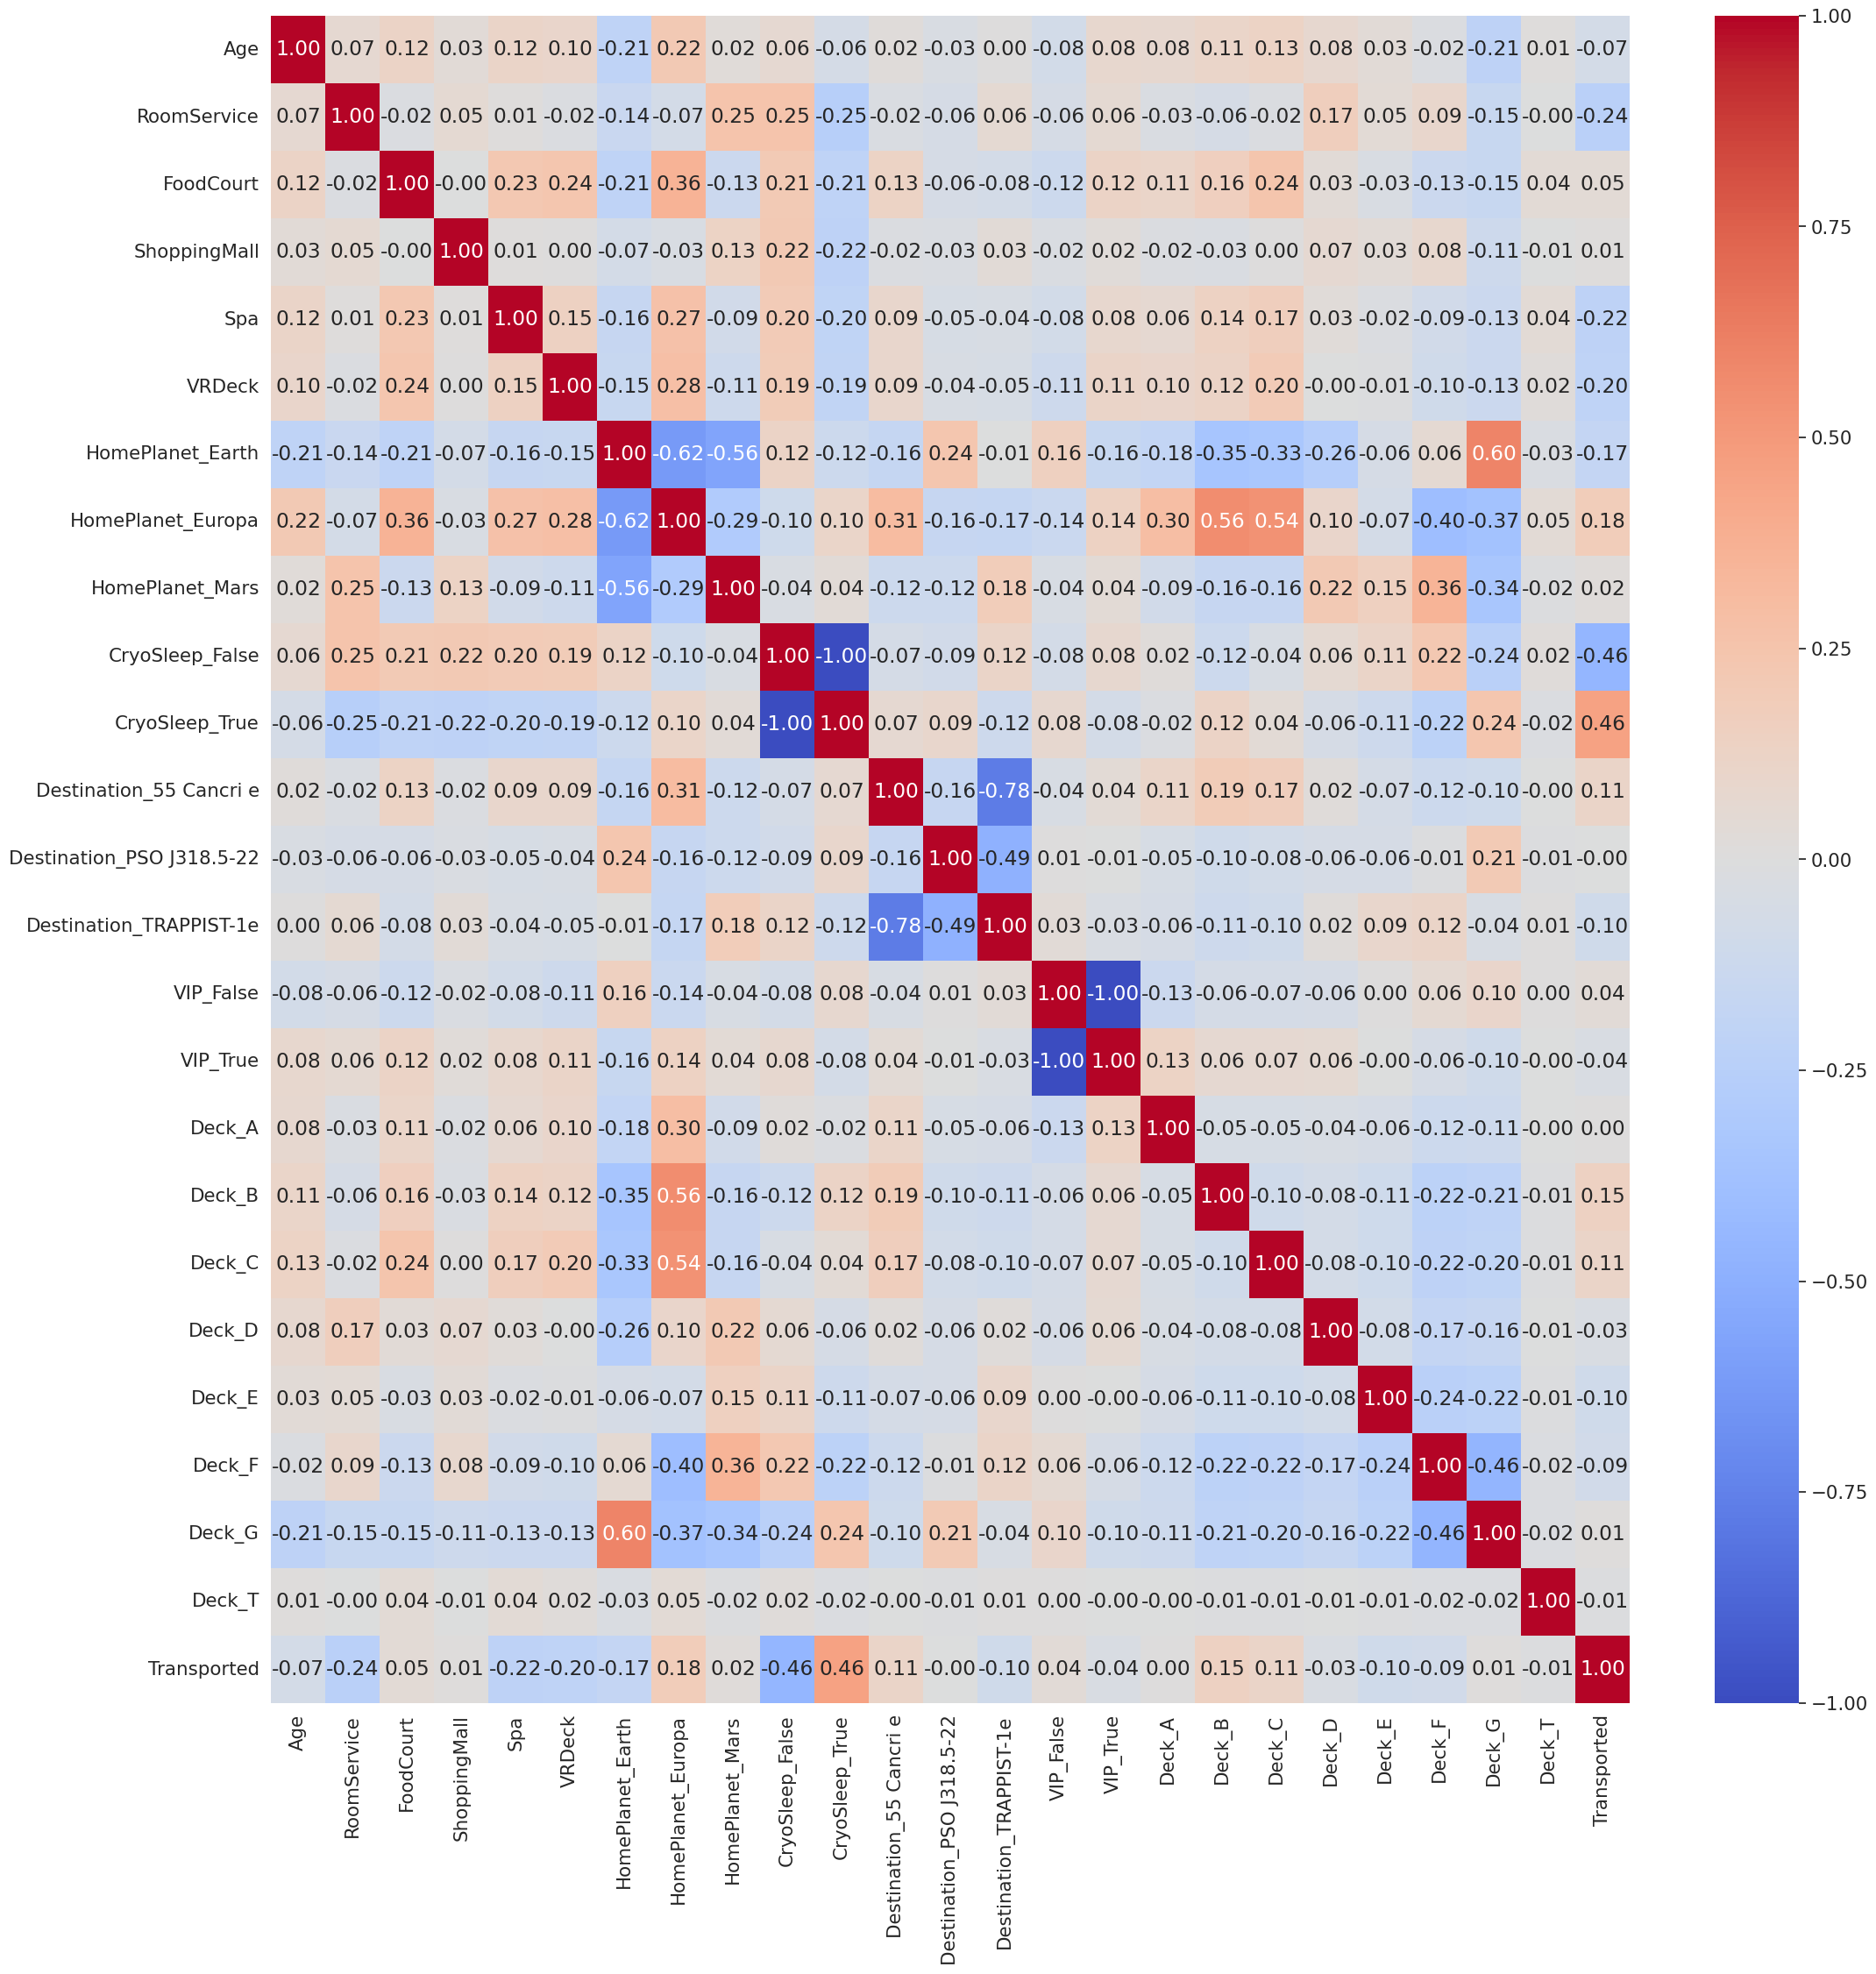

In [33]:
# 1. 상관관계 분석에 사용할 임시 데이터프레임 생성
temp_df = pd.concat([data, y], axis=1)

# 2. 모든 수치형 변수 사이의 상관관계 행렬 구하기
corr_matrix = temp_df.corr()

# 2. 히트뱁으로 시각화
plt.figure(figsize=(25, 25))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

<b>(1) 타겟 변수(Transported)와의 상관관계 분석 </b>
```
- 음의 상관관계 (생존율 상승) : CryoSleep_False(-0.46)가 가장 강한 음의 상관관계를 보이고, RoomService, Spa, VRDeck 같은 유료 서비스 지출도 생존율을 높이는 경향이 있다. (HomePlanet_Earth) 승객도 생존율이 다소 높게 나온다.
- 양의 상관관계 (생존율 감소) : CryoSleep_True(0.46)가 가장 강력한 부정적 요인입니다. 유럽 출신(HomePlanet_Europa)이거나 Deck_B, Deck_C 같은 특정 상급 덱에 탑승한 승객들이 다수 차원 이동으로 실종되었음을 알 수 있다.
```

<b>(2) 다중공선성(Multicollinearity) 분석과 피처 선택</b>
```
몇몇 변수들 사이에서 강한 상관관계가 관찰된다.
- 완벽한 중복 변수 제거 (VIP, CryoSleep) :   
VIP_False와 VIP_True가 -1.0, CryoSleep_False와 CryoSleep_True가 -1.0으로 완벽한 대칭을 이룬다. 완벽한 다중공선성이 발생하였으므로, 둘 중 하나를 삭제한다. VIP_True, CryoSleep_True를 남기도록 한다.
- 높은 상관관계 변수 검토 (HomePlanet, Destination, Deck):  
목적지 변수들 간의 -0.78이나 고향 행성 간의 -0.62 등은 원핫 인코딩 특성상 발생하는 자연스러운 음의 상관관계로 보인다.
행성과 덱 사이의 관계(HomePlanet_Earth ↔ Deck_G: 0.60, HomePlanet_Europa ↔ Deck_B: 0.56)는 "특정 행성 사람들이 특정 덱에 모여 탔다"는 유의미한 배경 정보를 담고 있으므로 그대로 유지하는 것이 모델 학습에 도움이 될 것으로 추정된다.
```


## 4.2 다중공선성 제거 및 피처 선택

In [34]:
# 다중공선성 해결을 위한 피처 삭제

data.drop(columns = ['VIP_False', 'CryoSleep_False'], inplace = True)

# <center>5. 모델링</center>

## 5.1 데이터 분리 (Train/Validation Split)

In [35]:
# 1. 학습데이터와 테스트데이터 분리
X = data.iloc[:train_len,]
sub = data.iloc[train_len:,]

# 2. 학습데이터 내에서 학습 데이터와 검증 데이터 분리 (난수값 지정)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state=2026)

print("X_train : {}".format(X_train.shape))
print("X_val : {}".format(X_val.shape))
print("y_train : {}".format(y_train.shape))
print("y_val : {}".format(y_val.shape))

X_train : (6954, 22)
X_val : (1739, 22)
y_train : (6954,)
y_val : (1739,)


## 5.2 기본 모델 선정 및 학습 (Baseline Models)

[LightGBM을 첫 번째 모델로 선택한 이유]
1. **대용량 데이터 및 빠른 학습 속도 (Speed):** 트리 기반 알고리즘 중에서도 리프 중심 트리 분할(Leaf-wise) 방식을 사용하여 속도가 매우 빠르고 메모리를 적게 소요함.
2. **높은 예측 성능 (Accuracy):** 범주형 변수가 많고 복잡한 관계를 가진 정형 데이터(Tabular Data) 분류 문제에서 강력한 성능을 보여줌
3. **과적합 방지 및 결측치 처리:** 자체적으로 결측치를 처리하는 기능이 내장되어 있으며, 규제 매개변수를 통해 과적합을 효과적으로 제어할 수 있음.

In [36]:
# 앞으로 사용할 모델 리스트에 저장
lgbm = LGBMClassifier(random_state=2026)
xgb = XGBClassifier(random_state=2026)
catboost = CatBoostClassifier(random_state=2026)
rf= RandomForestClassifier(random_state=2026)
logi = LogisticRegression(random_state=2026)

models = [lgbm, xgb, catboost, rf, logi]

# 모델 학습
lgbm.fit(X_train, y_train)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3496, number of negative: 3458
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000840 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1383
[LightGBM] [Info] Number of data points in the train set: 6954, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502732 -> initscore=0.010929
[LightGBM] [Info] Start training from score 0.010929


LGBMClassifier(random_state=2026)

## 5.3 모델 평가

In [37]:
# 검증 데이터를 활용해 예측값 구하기
y_pred = lgbm.predict(X_val)

# 정확도 계산하기
accuracy = accuracy_score(y_val, y_pred)
print(f"LightGBM Validation Accuracy: {accuracy:.4f}")

LightGBM Validation Accuracy: 0.7976


```
LightGBM 분류기 모델로 기본 학습을 한 결과, 정확도는 0.7976.
목표는 0.8 이상이므로 파생변수 추가, 모델 교차검증, 하이퍼파라미터 튜닝 등을 통해 성능을 높임.
```

## 5.4 피처 엔지니어링 (파생변수 추가)

1. **총 지출 금액 (`TotalSpend`)**
   * **이유:** `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck` 등 우주선 내 개별 유료 서비스 지출액은 각각 독립된 정보이다. 하지만 이를 하나로 합친 '총 지출 금액'을 만들면, 승객이 우주선 내에서 소비를 얼마나 적극적으로 했는지(VIP 성향, 특정 구역 체류 가능성)를 나타내는 강력한 단일 지표가 된다. 특히 냉동 수면 승객(`CryoSleep=True`)은 지출이 0원일 것이므로, 이들의 특징을 한 번 더 강화해 주는 효과가 있을 것으로 추정된다.

2. **나이 그룹 (`AgeGroup`)**
   * **이유:** 나이(`Age`)는 연속형 수치 데이터이다. 모델이 "1살 차이"에 민감하게 반응하기보다 영유아, 청소년, 성인, 노년층 등 특정 생애주기별로 묶어서 패턴을 학습할 때, 실종 여부와의 연관성을 더 쉽게 포착할 수 있을 것으로 예상한다. 예를 들어, 어린이 승객이 우선 구조되었거나 특정 연령대가 특정 구역에 모여 있었을 가능성을 반영할 수 있을 것이다.

In [38]:
# 총 지출 금액 변수 추가

# 더할 지출 컬럼들만 리스트로 지정
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

data['TotalSpend'] = data[spend_cols].sum(axis=1)
data['TotalSpend']

0            0.0
1          736.0
2        10383.0
3         5176.0
4         1091.0
          ...   
12965        0.0
12966     1018.0
12967        0.0
12968     3203.0
12969        0.0
Name: TotalSpend, Length: 12970, dtype: float64

In [39]:
# 나이 그룹 변수 추가

# 나이 경계선 설정 (0~12, 12~18, 18~60, 60~100)
age_bins = [0, 12, 18, 60, 100]

# 각 구간의 이름 설정
age_labels = ['Child', 'Teenager', 'Adult', 'Elderly']

data['AgeGroup'] = pd.cut(data['Age'], bins = age_bins, labels = age_labels)

# 범주형 변수 AgeGroup 원핫 인코딩
data = pd.get_dummies(data, columns = ['AgeGroup'])

data

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_True,...,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,TotalSpend,AgeGroup_Child,AgeGroup_Teenager,AgeGroup_Adult,AgeGroup_Elderly
0,39.0,0.0,0.0,0.0,0.0,0.0,False,True,False,False,...,False,False,False,False,False,0.0,False,False,True,False
1,24.0,109.0,9.0,25.0,549.0,44.0,True,False,False,False,...,False,False,True,False,False,736.0,False,False,True,False
2,58.0,43.0,3576.0,0.0,6715.0,49.0,False,True,False,False,...,False,False,False,False,False,10383.0,False,False,True,False
3,33.0,0.0,1283.0,371.0,3329.0,193.0,False,True,False,False,...,False,False,False,False,False,5176.0,False,False,True,False
4,16.0,303.0,70.0,151.0,565.0,2.0,True,False,False,False,...,False,False,True,False,False,1091.0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,34.0,0.0,0.0,0.0,0.0,0.0,True,False,False,True,...,False,False,False,True,False,0.0,False,False,True,False
12966,42.0,0.0,847.0,17.0,10.0,144.0,True,False,False,False,...,False,False,False,True,False,1018.0,False,False,True,False
12967,27.0,0.0,0.0,0.0,0.0,0.0,False,False,True,True,...,True,False,False,False,False,0.0,False,False,True,False
12968,27.0,0.0,2680.0,0.0,0.0,523.0,False,True,False,False,...,True,False,False,False,False,3203.0,False,False,True,False


## 5.5 교차 검증 (K-Fold Cross Validation)

In [40]:
# 파생변수가 추가된 data 데이터를 훈련데이터랑 테스트테이더로 나눔
X = data.iloc[:train_len]
sub = data.iloc[train_len:]

# 2. 학습데이터 내에서 학습 데이터와 검증 데이터 분리 (난수값 지정)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state=2026)

In [41]:
# 5-Folds 교차검증 함수 정의

def evaluate_model(model, X_data, y_data):
    # 5개의 폴드로 나누기 설정
    skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 2026)
    folds_scores = []

    for train_idx, val_idx in skf.split(X_data, y_data):
        X_train_fold, y_train_fold = X_data.iloc[train_idx], y_data.iloc[train_idx]
        X_val_fold, y_val_fold = X_data.iloc[val_idx], y_data.iloc[val_idx]

        # 모델 학습 시키기
        model.fit(X_train_fold, y_train_fold)

        # 예측하기
        pred = model.predict(X_val_fold)

        # 정확도 계산 후 리스트에 추가
        score = accuracy_score(y_val_fold, pred)
        folds_scores.append(score)

    # 최종 평균 점수 반환
    return np.mean(folds_scores)

In [42]:
# 파생변수를 포함한 새로운 훈련데이터셋의 모델 평가 점수 : CatBoost와 로지스틱회귀, RandomForest 함께 진행
# models = [lgbm, xgb, catboost, rf, logi]

lgbm_score = evaluate_model(lgbm, X, y)
cat_score = evaluate_model(catboost, X, y)
logi_score = evaluate_model(logi, X, y)
rf_score = evaluate_model(rf, X, y)

clear_output()

print(f"LGBM CV Score: {lgbm_score:.4f}")
print(f"CatBoost CV Score: {cat_score:.4f}")
print(f"Logistic Regression CV Score: {logi_score:.4f}")
print(f"RandomForest CV Score: {rf_score:.4f}")


LGBM CV Score: 0.8039
CatBoost CV Score: 0.8048
Logistic Regression CV Score: 0.7837
RandomForest CV Score: 0.7879


```
LightGBM 기준, 0.7976 에서 0.8039로 0.0063 상승.
CatBoost가 근소한 차이이지만 가장 높은 점수(0.8048)을 기록했으며,
Logistic Regression과 RandomForest는 0.1점 이상 차이가 나지만 기본 모델(LightGBM)과 성격이 다르므로 블렌딩 했을 때 시너지를 기대해 볼 수 있음.  
```

## 5.6 하이퍼파라미터 튜닝 (Grid/Random/Bayesian)

베이스라인 모델으로 삼은 LightGBM에 베이지안 최적화(HyperOpt)를 적용, 좀 더 정교한 하이퍼파라미터를 도출한다.   

---
<b>[핵심 파라미터]</b>
- learning_rate : 학습률 (모델 학습의 세밀한 정도 결정)
- max_depth : 트리 최대 깊이 (과적합 방지하는 구조적 한계)
- num_leaves : 하나의 트리가 가질 수 있는 최대 리프 노드 수

In [43]:
# LightGBM 하이퍼 파라미터 탐색 공간 정의

lgbm_space = {
    # 3부터 10까지 1 간격으로 정수 탐색
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    # max_depth에 맞춰서 리프 노드 개수 조절
    'num_leaves': hp.quniform('num_leaves', 15, 63, 1),
    # 0.01부터 0.2까지 연속적인 값 탐색
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2)
}


HyperOpt는 기본적으로 목적 함수의 반환값을 최소화 하는 방향으로 최적의 파라미터를 찾아감.
Accuracy를 높여아 하는 것이므로, Accuracy값에 -1를 곱해 음수로 만들어주면 HyperOpt음수 값을 최소화(즉, 절대값인 실제 정확도를 최대화)하게 됨.

In [47]:
# HyperOpt를 인식할 목적 함수(Objective Function)
def objective(params):

    # params는 HyperOpt가 제안하는 하이퍼파라미터 딕셔너리
    # 단, max_depth와 num_leaves는 정수형이어야 하므로 변환이 필요
    model_params = {
        'max_depth': int(params['max_depth']),
        'num_leaves': int(params['num_leaves']),
        'learning_rate': params['learning_rate'],
        'random_state': 2026
    }

    # 변경된 파라미터로 LightGBM 모델 생성
    model = LGBMClassifier(**model_params)

    # evaluate_model 함수로 교차검증 평균점수 계산
    score = evaluate_model(model, X, y)

    return -score

In [48]:
# HyperOpt 탐색은 fmin 함수 사용

# 탐색 과정을 기록할 Trials 객체
trials = Trials()

# 최적화 수행
best = fmin(
    fn = objective,                       # 목적 함수
    space = lgbm_space,                   # 탐색 공산
    algo = tpe.suggest,                   # 베이지안 최적화 알고리즘
    max_evals = 50,                       # 최대 시도 횟수
    trials = trials,                      # 결과 기록
    rstate = np.random.default_rng(2026)  # 랜덤 시드 고정
)

clear_output()

print("Best Hyper parameters : ", best)

Best Hyper parameters :  {'learning_rate': np.float64(0.10242010538810804), 'max_depth': np.float64(10.0), 'num_leaves': np.float64(22.0)}


```
HyperOpt 결과 최적의 파라미터값 : 'learning_rate': 0.1, 'max_depth': 10, 'num_leaves': 22
이를 LightGBM 모델에 적용.

블렌딩을 대비해서 CatBoost와 Logistic Regression 모델도 최적의 파라미터를 찾음.

```

In [49]:
# 수정된 LightGBM 적용 코드
lgbm_tuned = LGBMClassifier(
    max_depth=10,
    num_leaves=22,
    learning_rate=0.1,
    random_state=2026
)

lgbm_score_tuned = evaluate_model(lgbm_tuned, X, y)

clear_output()

print(f"LGBM tuned CV Score: {lgbm_score_tuned:.4f}")

LGBM tuned CV Score: 0.8051


In [50]:
# 블렝딩 후보인 CatBoost와 Logistic Regression도 HyperOpt로 최적화 수행

# 두 모델도 돌아갈 수 있도록 목적 함수 업데이트

def objective2(space):
    # 1. 어떤 모델을 튜닝할지 space['model_type']으로 구분
    model_type = space['model_type']

    # 2. 모델 타입에 따라 파라미터 세팅 및 객체 생성
    if model_type == 'lgbm':
        model = LGBMClassifier(
            max_depth=int(space['max_depth']),
            num_leaves=int(space['num_leaves']),
            learning_rate=space['learning_rate'],
            random_state=2026,
            verbose=-1 # 로그 숨기기
        )
        # 교차 검증 함수로 스코어 측정
        score = evaluate_model(model, X, y)

    elif model_type == 'cat':
        model = CatBoostClassifier(
            iterations=1500, # 조기 종료를 믿고 크게 고정
            depth=int(space['depth']),
            learning_rate=space['learning_rate'],
            l2_leaf_reg=space['l2_leaf_reg'],
            random_state=2026,
            verbose=False
        )
        # 내부에서 조기 종료(Early Stopping)를 작동
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50
        )
        pred = model.predict(X_val)
        score = accuracy_score(y_val, pred)

    elif model_type == 'logi':
        model = LogisticRegression(
            C=space['C'],
            penalty=space['penalty'],
            solver='liblinear' if space['penalty'] == 'l1' else 'lbfgs',
            random_state=2026,
            max_iter=1000
        )
        # 교차 검증 함수로 스코어 측정
        score = evaluate_model(model, X, y)

    # Hyperopt는 최소화가 목적이므로 음수로 반환
    return -score

In [51]:
# CatBoostClassifier 파라미터 최적화

catboost_space = {
    'model_type': 'cat',
    'depth': hp.quniform('depth', 4, 10, 1),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'l2_leaf_reg': hp.quniform('l2_leaf_reg', 1, 10, 1)
}

best_cat = fmin(
    fn=objective2,
    space=catboost_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials(),
    rstate=np.random.default_rng(2026)
)
print("Best CatBoost:", best_cat)

# Accuracy score : 0.810
# best param : 'depth': 9, 'l2_leaf_reg': 10, 'learning_rate': 0.11

100%|██████████| 50/50 [01:28<00:00,  1.78s/trial, best loss: -0.8102357676825762]
Best CatBoost: {'depth': np.float64(9.0), 'l2_leaf_reg': np.float64(10.0), 'learning_rate': np.float64(0.11820450758712739)}


In [52]:
# Logistic Regression 파라미터 최적화

logi_space = {
    'model_type': 'logi',
    'C': hp.loguniform('C', np.log(0.001), np.log(100)), # 로그 스케일 탐색
    'penalty': hp.choice('penalty', ['l1', 'l2'])
}

best_logi = fmin(
    fn=objective2,
    space=logi_space,
    algo=tpe.suggest,
    max_evals=30, # 선형 모델은 탐색 공간이 좁아 30회면 충분하다.
    trials=Trials(),
    rstate=np.random.default_rng(2026)
)

print("Best Logistic:", best_logi)

# Accuracy score : 0.79
# best param : 'C': 0.01, 'penalty': 0 => l1(lasso),

100%|██████████| 30/30 [00:23<00:00,  1.29trial/s, best loss: -0.7944314120452015]
Best Logistic: {'C': np.float64(0.015888488299714853), 'penalty': np.int64(0)}


## 5.7 모델 블렌딩 (Blending)

HyperOpt로 하이퍼파라미터 최적화를 진행한 결과,   
- LightGBMClassifier : 0.8051  
- CatBoostClassifier : 0.8102  
- Logistic Regression : 0.7944  

로 모델 평가 점수가 상승하였다.

하이퍼파라미터 튜닝을 통해 개별 모델의 성능을 최대한으로 끌어올렸으나, 단일 모델만으로는 특정 데이터 패턴에 대한 오예측을 완벽히 해결하는데 한계가 있다.   
이에 따라, 각 모델이 가진 고유의 예측 메커니즘 차이를 활용하는 모델 블렌딩을 시도한다.   

---

<b>1. 트리 모델의 상호 보완 (LightGBM + CatBoost)</b>
- LightGBM: 리프 중심 분할(Leaf-wise) 방식으로, 비대칭적이고 빠르게 최적의 손실 값을 찾아간다. 속도가 빠르고 수치형 변수의 미세한 경계선을 잘 잡아낸다.

- CatBoost: 대칭 트리(Symmetric Trees) 구조를 사용하여 과적합(Overfitting)을 강력하게 억제한다. 특히 원핫 인코딩을 했더라도 범주형 변수에서 유래된 피처들의 복잡한 상호작용을 안정적으로 포착한다.

- 결과: 두 모델을 섞으면 한쪽 트리 알고리즘이 놓친 데이터의 경계면을 다른 쪽 트리 알고리즘이 메워주는 효과가 난다.


<b>2. 구조가 다른 선형모형 추가(Logistic Regression)</b>
- 로지스틱 회귀는 데이터 전체를 관통하는 하나의 매끄러운 선형 결정 경계(Linear Decision Boundary)를 만든다.

- 트리 모델들이 과적합될 경우, 로지스틱 회귀의 부드러운 선형 예측 확률이 결합되면 전체적인 예측의 뾰족한 변동성을 깍아주면 완충 작용(Regulatization)을 해준다.


In [53]:
# 성격이 다른 모델들을 조합하므로, 성능이 높은 모델이 더 많은 비중을 두는 가중 평균 방식 사용
# 교차 검증 함수에 가중치 비교에 쓸 OOF 예측 확률 수집 기능 추가하여 업그레이드


def evaluate_model_oof(model, X_data, y_data):
    # 5개의 폴드로 나누기 설정
    skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 2026)
    folds_scores = []

    # 전체 데이터 크기만큼 0으로 채워진 빈 oof 배열 생성
    oof_preds = np.zeros(len(X_data))

    for train_idx, val_idx in skf.split(X_data, y_data):
        X_train_fold, y_train_fold = X_data.iloc[train_idx], y_data.iloc[train_idx]
        X_val_fold, y_val_fold = X_data.iloc[val_idx], y_data.iloc[val_idx]

        # 모델 학습 시키기
        model.fit(X_train_fold, y_train_fold)

        # 검증 데이터의 1일 확률 구하기
        val_preds_proba = model.predict_proba(X_val_fold)[:, 1]

        # 3. 원래 데이터의 검증 인덱스 위치(val_idx)에 확률을 저장
        oof_preds[val_idx] = val_preds_proba

        # 기존 정확도 계산을 위해 반올림(0.5 기준)하여 클래스로 변환 후 점수 기록
        val_preds_class = (val_preds_proba >= 0.5).astype(int)

        # 정확도 계산 후 리스트에 추가
        score = accuracy_score(y_val_fold, val_preds_class)
        folds_scores.append(score)

    # 최종 평균 점수 및 OOF 예측 배열 반환
    return np.mean(folds_scores), oof_preds

In [57]:
# 성격이 다른 모델들을 조합하므로, 성능이 높은 모델이 더 많은 비중을 두는 가중 평균 방식 사용

cat_tuned = CatBoostClassifier(
    depth= 9,
    l2_leaf_reg= 10,
    learning_rate= 0.1,
    random_state=2026
)

logi_tuned = LogisticRegression(
    C=0.015888488299714853,
    penalty='l1',            # Hyperopt 결과 인덱스 0은 'l1'을 의미
    solver='liblinear',      # l1 규제를 지원하는 solver 지정
    max_iter=1000,
    random_state=2026
)

# 모델별 점수와 OOF 배열 수집
lgbm_score, oof_lgbm = evaluate_model_oof(lgbm_tuned, X, y)
cat_score, oof_cat = evaluate_model_oof(cat_tuned, X, y)
logi_score, oof_logi = evaluate_model_oof(logi_tuned, X, y)

clear_output()


print("LGBM 모델 OOF 예측 배열 : {}".format(oof_lgbm))
print("CatBoost 모델 OOF 예측 배열 : {}".format(oof_cat))
print("Logistic Regression 모델 OOF 예측 배열 : {}".format(oof_logi))

LGBM 모델 OOF 예측 배열 : [0.77982745 0.17469017 0.00660039 ... 0.87582113 0.01534125 0.98077327]
CatBoost 모델 OOF 예측 배열 : [0.78981773 0.08277701 0.00171182 ... 0.98920741 0.00483531 0.99478343]
Logistic Regression 모델 OOF 예측 배열 : [7.58771814e-01 1.92892018e-01 7.58183859e-05 ... 6.75821886e-01
 1.78248878e-02 9.72714448e-01]


In [58]:
# 역대 최고 점수와 가중치를 기록할 변수 초기화
best_score = 0
best_weights = None

# 가중치 조합 탐색 시작 (0부터 1까지 21개의 구간으로 나눔)
for w_lgbm in np.linspace(0, 1, 21):
    for w_cat in np.linspace(0, 1 - w_lgbm, 21):
        # 세 가중치의 합이 1이 되도록 마지막 가중치 결정
        w_logi = 1.0 - w_lgbm - w_cat

        # 현재 가중치를 적용해 oof 예측 확률 합산
        blend_oof = (oof_lgbm * w_lgbm) + (oof_cat * w_cat) + (oof_logi * w_logi)

        # 임계값(0.5)을 적용해 클래스(0 또는 1)로 변환
        final_oof = (blend_oof >= 0.5).astype(int)

        # 전체 정답(y)와 비교하여 정확도 계산
        score = accuracy_score(y, final_oof)

        # 최고 점수를 갱신하면 가중치와 점수를 저장
        if score > best_score:
            best_score = score
            best_weights = (w_lgbm, w_cat, w_logi)

# 결과 출력
print(f"🏆 최적의 블렌딩 점수: {best_score:.4f}")
print(f"⚖️ 최적의 가중치 (LGBM, Cat, LR): {best_weights}")

🏆 최적의 블렌딩 점수: 0.8081
⚖️ 최적의 가중치 (LGBM, Cat, LR): (np.float64(0.75), np.float64(0.21250000000000002), np.float64(0.03749999999999998))


In [66]:
# 최적의 가중치 적용

# 각 모델로 최종 테스트 데이터의 1일 확률 예측
test_prob_lgbm = lgbm_tuned.predict_proba(sub)[:, 1]
test_prob_cat = cat_tuned.predict_proba(sub)[:, 1]
test_prob_logi = logi_tuned.predict_proba(sub)[:, 1]

# 찾은 최적의 가중치(75%, 21.25%, 3.75%) 적용하여 합산
final_test_prob = (test_prob_lgbm * 0.75) + (test_prob_cat * 0.2125) + (test_prob_logi * 0.0375)

# 임계값(0.5)을 적용해 최종 정답(true/false) 결정
final_test_pred = (final_test_prob >= 0.5)



# Kaggle Score : 0.79565

# 6. 서브미션 파일 내보내기

In [65]:
submission_path = './data/sample_submission.csv'
submission = pd.read_csv(submission_path)
submission['Transported'] = final_test_pred
submission.to_csv('./data/my_blending_submission.csv', index=False)
print("파일 추출 성공!")

파일 추출 성공!


<img src="./img/1.png">

# 7. NOTE

---

```
지난 퀘스트에 이어서 이번에도 Kaggle 데이터 셋으로 분석 및 모델 구축을 연습해보았다.
이번에는 EDA와 데이터 전처리에 많은 시간을 할애하였다. 나름 논리를 구축하면서 전처리를 수행한 것에 대해서 만족한다.

다만 여기서 시간을 많이 소비하는 바람에 모델링을 하는데 시간이 부족했다.
다행히 GridSearch를 사용했던 저번 퀘스트와 달리, 이번에는 HyperOpt(베이지안 최적화)를 사용하여 그리드 탐색에 비해 모델링 분석 시간을 단축시킬 수 있었다.

로컬에서 받은 점수는 0.8081 이었지만 Kaggle의 leaderboard 상 스코어는 0.79565에 그쳤다.
로컬에서 점수가 괜찮아서 HyperOpt가 도출한 최적값을 믿었는데, 역시 다 믿어서는 안되나보다. 결국은 사람이 직접 이리저리 해봐야 하는 것 같다.
좀 더 시간적 여유가 있다면 파생변수와 파라미터값을 변경해 0.805 이상에 도전하고 싶다.

```

# 8. Reference

---
- 대회 페이지  

    Kaggle, Spaceship Titinic  
    https://www.kaggle.com/competitions/spaceship-titanic


- 참고 솔루션   

    MUSA KHAN, Spaceship Titanic-Top 6%|For Beginners
    https://www.kaggle.com/code/lazer999/spaceship-titanic-top-6-for-beginners

    MINATO NAKIKAZE, Space Titanic| EDA|Advanced Feature Engineering
    https://www.kaggle.com/code/arunklenin/space-titanic-eda-advanced-feature-engineering

- 모델링 참고

    김채운, [머신러닝] LightGBM & HyperOpt: 더 빠르고 똑똑하게 모델 튜닝하기
    https://velog.io/@aabb510/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D-LightGBM-HyperOpt-%EB%8D%94-%EB%B9%A0%EB%A5%B4%EA%B3%A0-%EB%98%91%EB%98%91%ED%95%98%EA%B2%8C-%EB%AA%A8%EB%8D%B8-%ED%8A%9C%EB%8B%9D%ED%95%98%EA%B8%B0

    Go Lab, lightGBM / XGBoost 파라미터 설명
    http://machinelearningkorea.com/2019/09/29/lightgbm-%ED%8C%8C%EB%9D%BC%EB%AF%B8%ED%84%B0/


#